In [1]:
%load_ext autoreload
%autoreload 2

import os
import glob
import sys
sys.path.insert(0, "../")

import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib
from matplotlib import pyplot as plt
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# %matplotlib inline
%config InlineBackend.figure_formats = {'png', 'retina'}

import warnings
warnings.simplefilter("ignore")

pd.set_option('display.precision', 1)

def get_missing_combinations(
    df,
    x_col,
    hue_col,
    y_col,
    x_order=None,
    hue_order=None,
):
    """
    Return missing (x, hue) combinations after filtering rows with missing y values.
    """
    plot_df = df.dropna(subset=[y_col]).copy()

    if x_order is None:
        x_order = sorted(df[x_col].dropna().unique())
    if hue_order is None:
        hue_order = list(df[hue_col].dropna().unique())

    expected = pd.MultiIndex.from_product(
        [x_order, hue_order],
        names=[x_col, hue_col]
    )

    present = (
        plot_df[[x_col, hue_col]]
        .dropna()
        .drop_duplicates()
        .set_index([x_col, hue_col])
        .index
    )

    missing = expected.difference(present)
    return plot_df, list(x_order), list(hue_order), missing


def add_missing_x_markers(
    ax,
    missing,
    x_order,
    hue_order,
    y_pos=None,
    log_scale=True,
    marker="x",
    color="red",
    markersize=7,
    markeredgewidth=2,
    group_width=0.8,
):
    """
    Plot markers at missing (x, hue) positions for a seaborn categorical plot.
    """
    if len(missing) == 0:
        return

    ymin, ymax = ax.get_ylim()

    if y_pos is None:
        if log_scale:
            y_pos = 10 ** (
                np.log10(ymin) + 0.06 * (np.log10(ymax) - np.log10(ymin))
            )
        else:
            y_pos = ymin + 0.06 * (ymax - ymin)

    n_hue = len(hue_order)
    step = group_width / n_hue

    for x_val, hue_val in missing:
        x_center = x_order.index(x_val)
        h = hue_order.index(hue_val)
        x_pos = x_center - group_width / 2 + step / 2 + h * step

        ax.plot(
            x_pos,
            y_pos,
            marker=marker,
            color=color,
            markersize=markersize,
            mew=markeredgewidth,
            linestyle="None",
            zorder=20,
            clip_on=False,
        )


def color_missing_legend_labels(
    legend,
    missing,
    color="red",
):
    """
    Color legend text for hue labels that appear in any missing (x, hue) combination.
    """
    missing_hues = {hue for _, hue in missing}

    for text in legend.get_texts():
        if text.get_text() in missing_hues:
            text.set_color(color)
            
def load_scampi(df_all):
    paths = {
        "scampi 8GB" : "../tests/results/scampi_8GB",
    }
    
    for name in paths:
        dir_path = paths[name]
        if os.path.isdir(dir_path):
            print(f"Reading from{dir_path}")
            json_files = glob.glob(os.path.join(dir_path, "*.json"))
            dfs = [pd.read_json(file) for file in json_files]
        
            for key, df in zip(json_files, dfs):
                filename = os.path.basename(key)
                end = filename.find("pyattimo")
                df["dataset"] = filename[14:end-4]                
                
            df_config = pd.concat(dfs, ignore_index=True)
            df_config["version"] = name
            df_config["backend"] = name

            df_config["extent"] = df_config["extent"].apply(lambda l : l[-1])
            df_config["motiflet"] = df_config["motiflet"].apply(lambda l : l[-1])

            # df_config.info()
            
            df_all = pd.concat([df_all, df_config], ignore_index=True)
        else:
            print("Does not exist")

    return df_all


def load_scalable(df_all):
    paths = {
        "scalable_sub": "../tests/results/scalable_sub",    
    }
    
    for name in paths:
        dir_path = paths[name]
        if os.path.isdir(dir_path):
            print(f"Reading from{dir_path}")
            csv_files = glob.glob(os.path.join(dir_path, "*.csv"))
            dfs = [pd.read_csv(file) for file in csv_files]
            
            for key, df in zip(csv_files, dfs):
                factor = key.split("_")[-1][:-4]
                filename = os.path.basename(key)
                end = filename.find("scalable")
                df["dataset"] = filename[14:end-4]            
                df["version"] = "MASS / PAA " + key.split("_")[-1][:-4]
                df["sampling"] = key.split("_")[-1][:-4]
                    
            df_config = pd.concat(dfs, ignore_index=True)
            df_all = pd.concat([df_all, df_config], ignore_index=True)
        else:
            print("Does not exist")

    return df_all

def load_pynndescent(df_all):
    paths = {
        "pynndescent": "../tests/results/pynndescent",    
    }
    
    for name in paths:
        dir_path = paths[name]
        if os.path.isdir(dir_path):
            print(f"Reading from{dir_path}")
            csv_files = glob.glob(os.path.join(dir_path, "*.csv"))
            dfs = [pd.read_csv(file) for file in csv_files]
            
            for key, df in zip(csv_files, dfs):
                filename = os.path.basename(key)
                end = filename.find("pynndescent")
                df["dataset"] = filename[14:end-4]            
                df["version"] = "pynndescent"
            
            df_config = pd.concat(dfs, ignore_index=True)
            df_all = pd.concat([df_all, df_config], ignore_index=True)
        
            # display(df_config)
        else:
            print("Does not exist")
                
    return df_all

def load_faiss(df_all):
    paths = {
        "HNSW": "../tests/results/faiss_HNSW",
        "IVF": "../tests/results/faiss_IVF",
        "LSH": "../tests/results/faiss_LSH_1bit",
        "IVFPQ": "../tests/results/faiss_IVFPQ",
    }
    
    for name in paths:
        dir_path = paths[name]
        if os.path.isdir(dir_path):
            print(f"Reading from{dir_path}")
            csv_files = glob.glob(os.path.join(dir_path, "*.csv"))
            dfs = [pd.read_csv(file) for file in csv_files]
            
            for key, df in zip(csv_files, dfs):
                filename = os.path.basename(key)
                end = filename.find("faiss_backend")
                df["dataset"] = filename[14:end-4]
                # print(filename[14:end-4])
                df["version"] = name
            
            df_config = pd.concat(dfs, ignore_index=True)
            df_all = pd.concat([df_all, df_config], ignore_index=True)
    
            # display(df_config)
        else:
            print("Does not exist")

    return df_all        



def load_latentmotifs(df_all):
    paths = {
        # "latentmotifs_r2": "../tests/results/latentmotifs_r2",
        # "latentmotifs_2r": "../tests/results/latentmotifs_2r",
        "latentmotifs": "../tests/results/latentmotifs_converted",
    }
    
    for name in paths:
        dir_path = paths[name]
        if os.path.isdir(dir_path):
            print(f"Reading from{dir_path}")
            csv_files = glob.glob(os.path.join(dir_path, "*.csv"))
            dfs = [pd.read_csv(file) for file in csv_files]
            
            for key, df in zip(csv_files, dfs):
                filename = os.path.basename(key)
                end = filename.find("latentmotifs")
                df["dataset"] = filename[14:end-4]
                df["version"] = name
                df["backend"] = name
                # print(filename[14:end-4])
                df["extent"] = np.nan
            
            df_config = pd.concat(dfs, ignore_index=True)
            df_all = pd.concat([df_all, df_config], ignore_index=True)
    
            # display(df_config)
        else:
            print("Does not exist")

    return df_all        


def load_momp_conv(df_all):
    paths = {
        "MOMP": "../tests/results/momp_converted2",
    }
    
    for name in paths:
        dir_path = paths[name]
        if os.path.isdir(dir_path):
            print(f"Reading from{dir_path}")
            csv_files = glob.glob(os.path.join(dir_path, "*.csv"))
            dfs = [pd.read_csv(file) for file in csv_files]
            
            for key, df in zip(csv_files, dfs):
                filename = os.path.basename(key)
                df["dataset"] = filename[5:len(filename)-4]
                df["version"] = name
                df["memory in MB"] = np.nan
            
            df_config = pd.concat(dfs, ignore_index=True)
            df_all = pd.concat([df_all, df_config], ignore_index=True)
    
            # display(df_config)
        else:
            print("Does not exist")

    return df_all        


def load_momp(df_all):
    path = "../tests/results/momp/momp.csv"
    print(f"Reading from{path}")
    df = pd.read_csv(path)
    df["version"] = df.backend
    # df["motif length"] = 4096
    df_all = pd.concat([df_all, df], ignore_index=True)
    return df_all


In [2]:
df_all = pd.DataFrame()
df_all = load_scampi(df_all)
df_all = load_scalable(df_all)
df_all = load_faiss(df_all)
df_all = load_pynndescent(df_all)
df_all = load_latentmotifs(df_all)
# df_all = load_momp(df_all)
df_all = load_momp_conv(df_all)

# not enough data from all datasets for l=8192
df_all = df_all[df_all["motif length"] <= 4096]
df_all["extent"] = np.sqrt(df_all["extent"])

df_all.loc[df_all.version == "latentmotifs_2r", "version"] = "LM 2"
df_all.loc[df_all.version == "latentmotifs", "version"] = "LM"
df_all.loc[df_all.version == "scampi 8GB", "version"] = "SCAMPI"
df_all.loc[df_all.version == "attimo", "version"] = "ATTIMO"
df_all.loc[df_all.version == "IVFPQ", "version"] = "FAISS (IVFPQ)"
df_all.loc[df_all.version == "HNSW", "version"] = "FAISS (HNSW)"
df_all.loc[df_all.version == "LSH", "version"] = "FAISS (LSH)"
df_all.loc[df_all.version == "IVF", "version"] = "FAISS (IVF)"
df_all.loc[df_all.version == "IVFPQ", "version"] = "FAISS (IVFPQ)"
df_all.loc[df_all.version == "pynndescent", "version"] = "pynndescent"
df_all.loc[df_all.version == "exact (projected)", "version"] = "MASS$^*$"

subset = df_all.loc[df_all.version == "MASS / PAA 16"].copy()
subset.loc[subset.version == "MASS / PAA 16", "time in s"] *= 16**2
subset.loc[subset.version == "MASS / PAA 16", "extent"] *= np.nan
subset.loc[subset.version == "MASS / PAA 16", "memory in MB"] *= np.nan
subset.loc[subset.version == "MASS / PAA 16", "version"] = "Exact$^*$"
subset.loc[subset.version == "MASS / PAA 16", "backend"] = "Exact$^*$"
df_all = pd.concat([df_all, subset], ignore_index=True)

display(df_all.version.unique())

Reading from../tests/results/scampi_8GB
Reading from../tests/results/scalable_sub
Reading from../tests/results/faiss_HNSW
Reading from../tests/results/faiss_IVF
Reading from../tests/results/faiss_LSH_1bit
Reading from../tests/results/faiss_IVFPQ
Reading from../tests/results/pynndescent
Reading from../tests/results/latentmotifs_converted
Reading from../tests/results/momp_converted2


array(['SCAMPI', 'MASS / PAA 16', 'MASS / PAA 8', 'MASS / PAA 64',
       'MASS / PAA 32', 'FAISS (HNSW)', 'FAISS (IVF)', 'FAISS (LSH)',
       'FAISS (IVFPQ)', 'pynndescent', 'LM', 'MOMP', 'Exact$^*$'],
      dtype=object)

In [44]:
import numpy
minima = df_all.groupby(["dataset", "motif length"], as_index=False)["extent"].min()
numpy.sqrt(minima["motif length"].astype(np.float))

AttributeError: module 'numpy' has no attribute 'float'.
`np.float` was a deprecated alias for the builtin `float`. To avoid this error in existing code, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations

In [3]:
print("Total number of datasets:    ", df_all.dataset.unique().shape[0])

# Filter
counts = df_all.groupby(["dataset", "version"]).size()
counts_df = counts.reset_index(name='count')

display(counts_df[counts_df.version == "ATTIMO"])
count_versions = df_all.version.nunique()

# display("count", count_versions)

# filter datasets where not all indices ran
def all_counts_equal(group):
    return group['version'].nunique() >= count_versions-2 # & (group['count'].min() >= 4)

datasets_to_keep = counts_df.groupby('dataset').filter(all_counts_equal)['dataset'].unique()
print("Filtered number of datasets: ", datasets_to_keep.shape[0])

filtered_df = df_all[df_all["dataset"].isin(datasets_to_keep)]
filtered_df = filtered_df[filtered_df["motif length"] <= 4096]

custom_order = ["SCAMPI",
                "FAISS (IVFPQ)",
                "FAISS (HNSW)",
                "FAISS (LSH)",
                "FAISS (IVF)",
                "FAISS (IVFPQ)",
                "pynndescent",
                "MOMP",
                "LM",
                "LM 2",
                "Exact$^*$"                
               ]

filtered_df = filtered_df[filtered_df.version.isin(custom_order)].copy()
filtered_df = filtered_df[filtered_df.length < 10_000_000]

display(filtered_df.version.unique())

display(filtered_df.dataset.unique())

Total number of datasets:     24


,dataset,version,count


Filtered number of datasets:  20


array(['SCAMPI', 'FAISS (HNSW)', 'FAISS (IVF)', 'FAISS (LSH)',
       'FAISS (IVFPQ)', 'pynndescent', 'LM', 'MOMP', 'Exact$^*$'],
      dtype=object)

array(['stator_winding', 'HAR_Ambient_Sensor_Data', 'house',
       'Lab_FD_061014', 'EOG_one_hour_400_Hz', 'swtAttack38',
       'MGHSleepElectromyography', 'WindTurbine', 'SpainishEnergyDataset',
       'solarwind', 'EOG_one_hour_50_Hz', 'swtAttack7',
       'Challenge2009Respiration500HZ', 'Lab_K_060314', 'CinC_Challenge',
       'Challenge2009TestSetA_101a', 'Bird12-Week3_2018_1_10', 'water',
       'BlackLeggedKittiwake'], dtype=object)

In [4]:
unique_versions = filtered_df['version'].unique()  # Or your full df if needed
version_order = [
    'SCAMPI', 'Exact$^*$', 
    'FAISS (HNSW)', 'FAISS (IVF)', 'FAISS (IVFPQ)', 'FAISS (LSH)', 
    'pynndescent', 'MOMP',  'LM']
n_versions = len(version_order)
colors = sns.color_palette("husl", n_versions)  # Or "muted", "Set2", etc.

print(unique_versions)

['SCAMPI' 'FAISS (HNSW)' 'FAISS (IVF)' 'FAISS (LSH)' 'FAISS (IVFPQ)'
 'pynndescent' 'LM' 'MOMP' 'Exact$^*$']


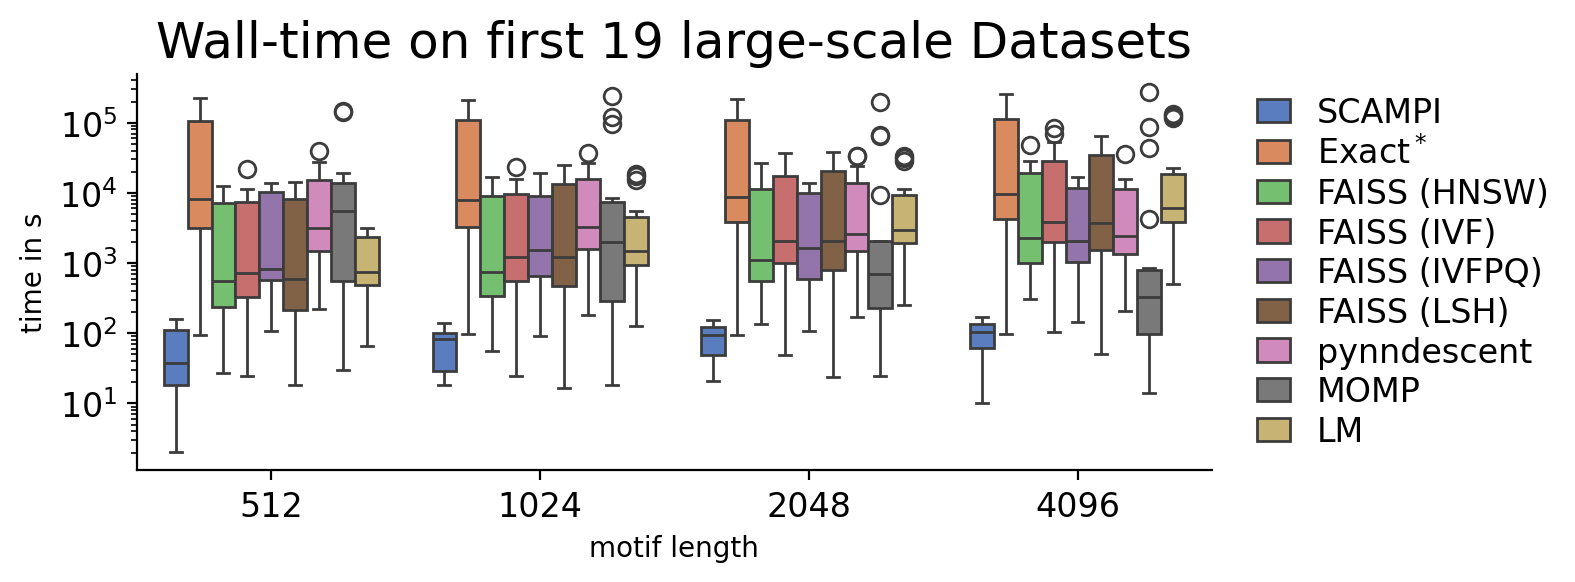

In [5]:
fig, ax = plt.subplots(figsize=(8, 3))

plot_df, all_x, all_versions, missing = get_missing_combinations(
    df=filtered_df,
    x_col="motif length",
    hue_col="version",
    y_col="time in s",
    x_order=sorted(filtered_df["motif length"].dropna().unique()),
    hue_order=version_order,
)

sns.boxplot(
    y="time in s",
    hue="version",
    x="motif length",
    data=plot_df,
    order=all_x,
    hue_order=all_versions,
    palette="muted",
    ax=ax,
)

ax.tick_params(axis="both", which="major", labelsize=12)

sns.despine()
ax.set_title(
    f"Wall-time on first {filtered_df.dataset.nunique()} large-scale Datasets",
    fontsize=18,
)
ax.set_yscale("log")

add_missing_x_markers(
    ax=ax,
    missing=missing,
    x_order=all_x,
    hue_order=all_versions,
    log_scale=True,
)

handles, labels = ax.get_legend_handles_labels()
leg = ax.legend(
    handles=handles,
    labels=labels,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=12,
    handlelength=1.0,
    borderpad=0.2,
    labelspacing=0.2,
    columnspacing=0.5,
    frameon=False,
)

color_missing_legend_labels(
    legend=leg,
    missing=missing,
    color="red",
)

plt.tight_layout()
plt.savefig("images/boxplot_runtime.pdf", bbox_inches="tight")
plt.show()

In [6]:
time = filtered_df.dropna(subset="time in s").groupby("version") \
    .agg({"time in s": ["min","max"]})

# extent["memory in MB"] = memory
display(time)

time in s          
                    min       max
version                          
Exact$^*$          92.9  252372.1
FAISS (HNSW)       27.6   48360.9
FAISS (IVF)        24.8   84600.5
FAISS (IVFPQ)      92.6   19150.3
FAISS (LSH)        16.5   65012.4
LM                 65.5  133762.8
MOMP               14.2  276059.1
SCAMPI              2.0     172.4
pynndescent       170.6   39682.0

In [7]:
time = filtered_df.dropna(subset="time in s").groupby("version") \
    .agg({"time in s":"sum"}).transform(lambda l: l / 3600 ) \
    .rename(columns={"time in s":"time in hours"})

extent = filtered_df.groupby("version") \
    .agg({"extent":["mean", "median"], "memory in MB":["mean", "median"]})

extent["time in hours"] = time

# extent["memory in MB"] = memory
display(extent.sort_values(("extent", "median")))
print(extent.sort_values(("extent", "median")).to_latex(float_format=lambda x: '%.1f' % x))

extent        memory in MB          time in hours
                mean median         mean   median              
version                                                        
SCAMPI           9.6    4.3       6601.5   8622.4           1.7
MOMP            23.4   15.7          NaN      NaN         453.7
pynndescent     44.4   41.4     126433.5  80584.2         177.3
FAISS (IVFPQ)   46.1   42.1      57288.5  32736.2         108.4
FAISS (HNSW)    46.2   42.5      84473.5  47237.6         135.3
FAISS (IVF)     46.2   42.5      91238.0  53992.6         208.5
FAISS (LSH)     46.6   43.1      57988.1  32942.5         222.4
Exact$^*$        NaN    NaN          NaN      NaN        1338.0
LM               NaN    NaN      53982.0  29059.5         210.7

\begin{tabular}{lrrrrr}
\toprule
 & \multicolumn{2}{r}{extent} & \multicolumn{2}{r}{memory in MB} & time in hours \\
 & mean & median & mean & median &  \\
version &  &  &  &  &  \\
\midrule
SCAMPI & 9.6 & 4.3 & 6601.5 & 8622.4 & 1.7 \\
MOMP & 23.4 & 15.7 & NaN & NaN & 453.7 \\
pynndescent & 44.4 & 41.4 & 126433.5 & 80584.2 & 177.3 \\
FAISS (IVFPQ) & 46.1 & 42.1 & 57288.5 & 32736.2 & 108.4 \\
FAISS (HNSW) & 46.2 & 42.5 & 84473.5 & 47237.6 & 135.3 \\
FAISS (IVF) & 46.2 & 42.5 & 91238.0 & 53992.6 & 208.5 \\
FAISS (LSH) & 46.6 & 43.1 & 57988.1 & 32942.5 & 222.4 \\
Exact$^*$ & NaN & NaN & NaN & NaN & 1338.0 \\
LM & NaN & NaN & 53982.0 & 29059.5 & 210.7 \\
\bottomrule
\end{tabular}



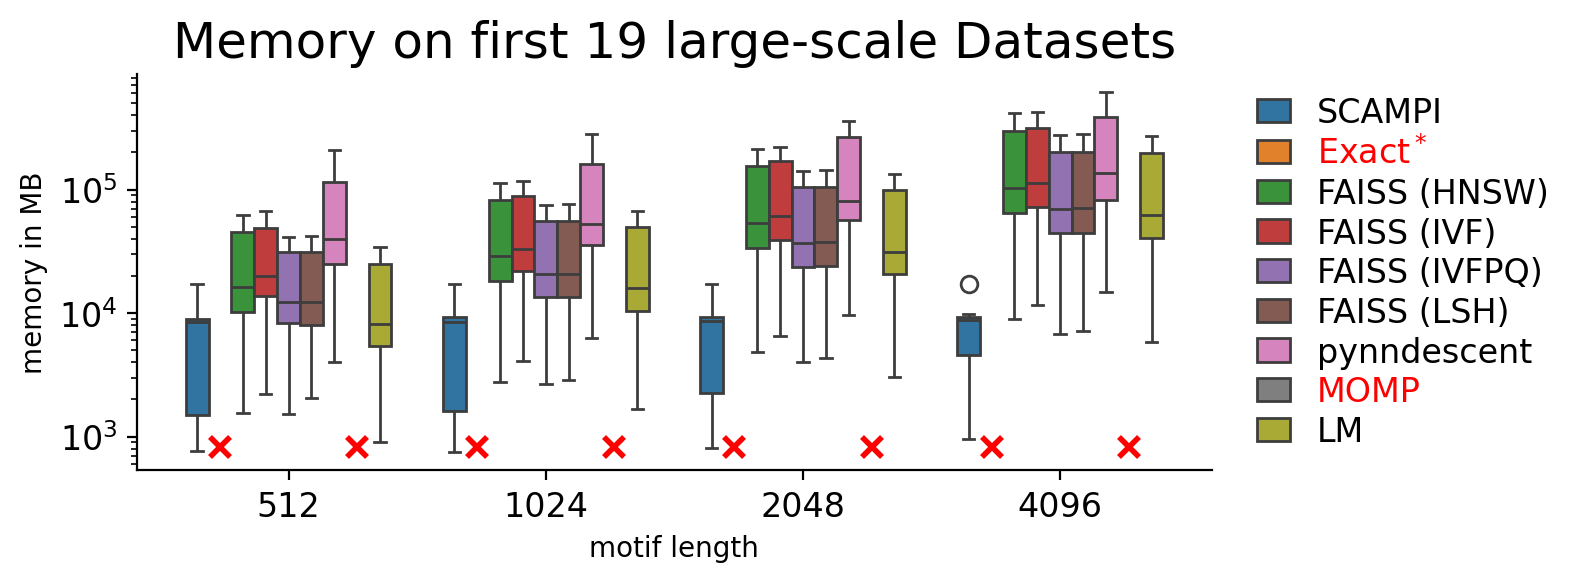

In [8]:
fig, ax = plt.subplots(figsize=(8, 3))

plot_df, all_x, all_versions, missing = get_missing_combinations(
    df=filtered_df,
    x_col="motif length",
    hue_col="version",
    y_col="memory in MB",
    x_order=sorted(filtered_df["motif length"].dropna().unique()),
    hue_order=version_order,
)

sns.boxplot(
    y="memory in MB",
    hue="version",
    x="motif length",
    data=plot_df,
    order=all_x,
    hue_order=all_versions,
    ax=ax,
)

ax.tick_params(axis="both", which="major", labelsize=12)
sns.despine()
ax.set_title(
    f"Memory on first {filtered_df.dataset.nunique()} large-scale Datasets",
    fontsize=18
)
ax.set_yscale("log")

add_missing_x_markers(
    ax=ax,
    missing=missing,
    x_order=all_x,
    hue_order=all_versions,
    log_scale=True,
)

handles, labels = ax.get_legend_handles_labels()
leg = ax.legend(
    handles=handles,
    labels=labels,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=12,
    handlelength=1.0,
    borderpad=0.2,
    labelspacing=0.2,
    columnspacing=0.5,
    frameon=False,
)

color_missing_legend_labels(
    legend=leg,
    missing=missing,
    color="red",
)

plt.tight_layout()
plt.savefig("images/boxplot_memory.pdf", bbox_inches="tight")
plt.show()

In [9]:
filtered_df.dropna(subset="memory in MB") \
    .pivot_table(
        values=["memory in MB"], 
        index=["version"], 
        columns=["motif length"], 
        aggfunc='median')

memory in MB                            
motif length          512      1024     2048      4096
version                                               
FAISS (HNSW)       16388.9  28867.7  53533.7  102686.7
FAISS (IVF)        19854.4  33226.0  60713.6  112879.1
FAISS (IVFPQ)      12358.9  20643.0  37115.6   69935.6
FAISS (LSH)        12195.4  20698.4  37427.2   70813.2
LM                  8104.7  15894.5  31418.3   62392.5
SCAMPI              8431.3   8446.8   8702.4    8864.1
pynndescent        39844.9  52784.6  80584.2  135553.3

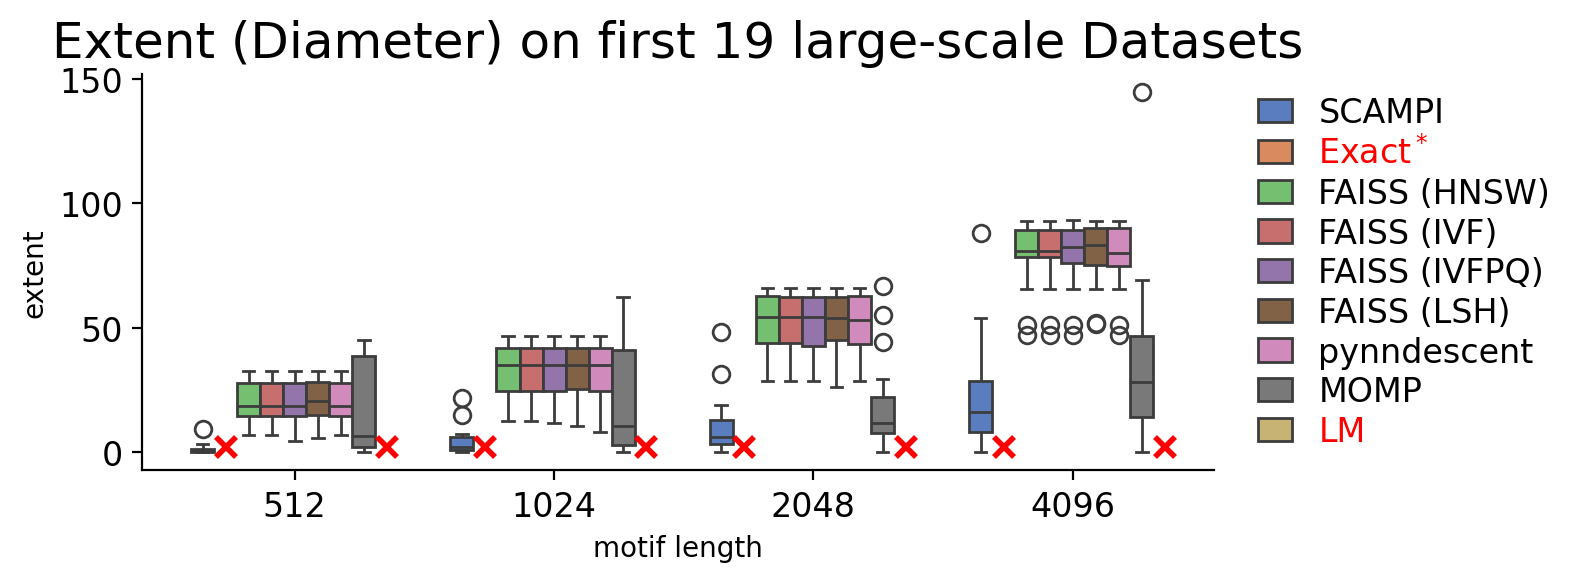

In [10]:
fig, ax = plt.subplots(figsize=(8, 3))

plot_df, all_x, all_versions, missing = get_missing_combinations(
    df=filtered_df,
    x_col="motif length",
    hue_col="version",
    y_col="extent",
    x_order=sorted(filtered_df["motif length"].dropna().unique()),
    hue_order=version_order,
)

sns.boxplot(
    y="extent",
    hue="version",
    x="motif length",
    data=plot_df,
    order=all_x,
    hue_order=all_versions,
    palette="muted",
    ax=ax,
)

ax.tick_params(axis="both", which="major", labelsize=12)

sns.despine()
ax.set_title(
    f"Extent (Diameter) on first {filtered_df.dataset.nunique()} large-scale Datasets",
    fontsize=18,
)
# ax.set_ylim([-1000, 10000])

add_missing_x_markers(
    ax=ax,
    missing=missing,
    x_order=all_x,
    hue_order=all_versions,
    log_scale=False,
)

handles, labels = ax.get_legend_handles_labels()
leg = ax.legend(
    handles=handles,
    labels=labels,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=12,
    handlelength=1.0,
    borderpad=0.2,
    labelspacing=0.2,
    columnspacing=0.5,
    frameon=False,
)

color_missing_legend_labels(
    legend=leg,
    missing=missing,
    color="red",
)

plt.tight_layout()
plt.savefig("images/boxplot_extent.pdf", bbox_inches="tight")
plt.show()

In [11]:
filtered_df.dropna(subset="extent") \
    .pivot_table(
        values=["extent"], 
        index=["version"], 
        columns=["motif length"], 
        aggfunc='mean')

extent                  
motif length    512   1024  2048  4096
version                               
FAISS (HNSW)    20.7  32.6  51.9  79.5
FAISS (IVF)     20.7  32.6  51.9  79.5
FAISS (IVFPQ)   20.3  33.0  51.8  79.5
FAISS (LSH)     21.1  33.0  52.5  79.9
MOMP            17.9  20.8  19.3  35.3
SCAMPI           1.4   4.6  10.2  22.1
pynndescent     20.6  32.3  51.6  78.7

In [12]:
# filtered_df.dataset.unique()

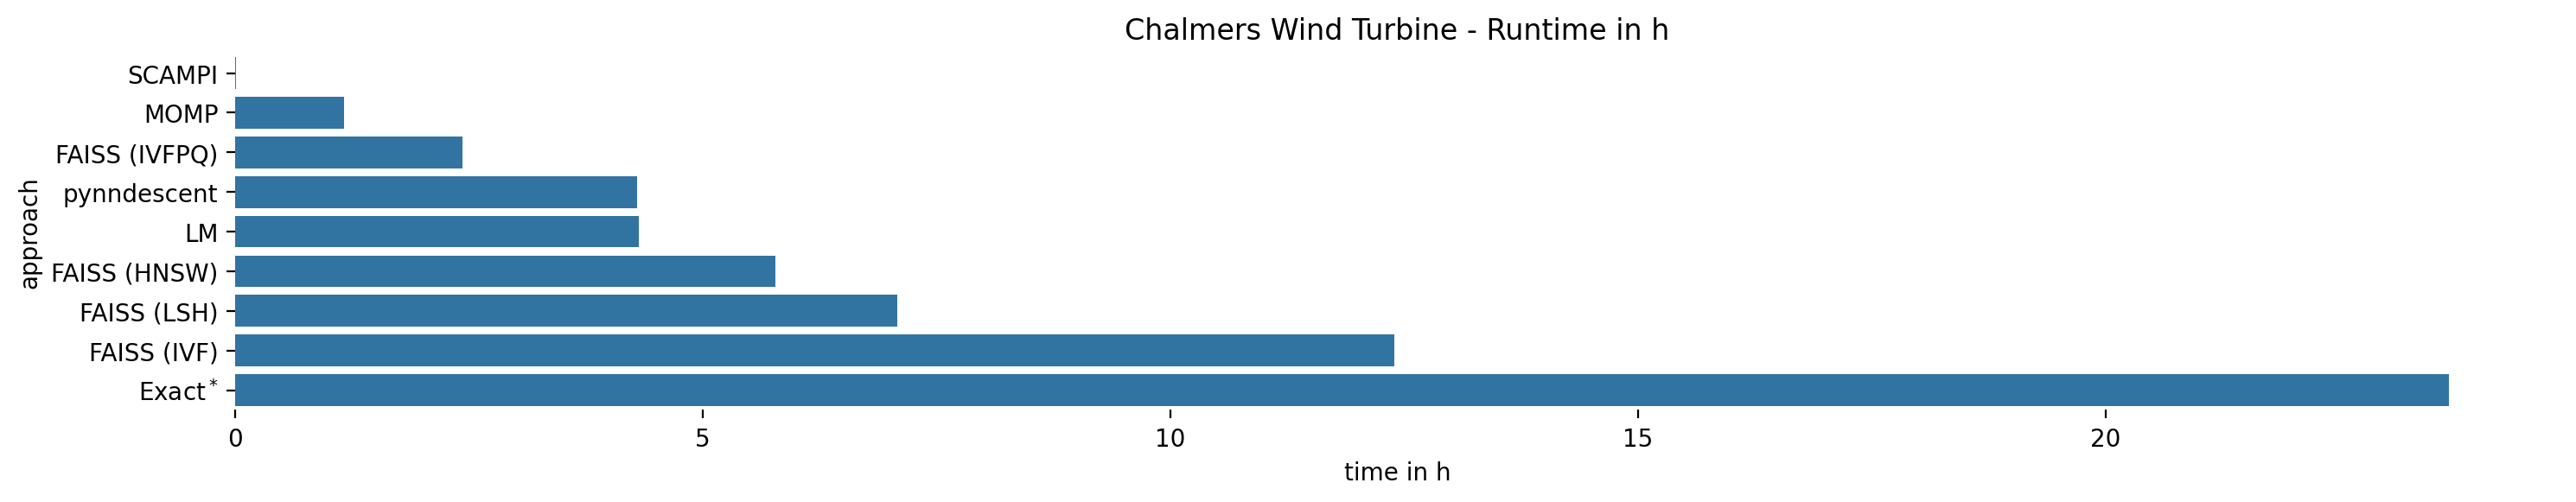

In [13]:
ds = "WindTurbine"
subset = filtered_df[(filtered_df.dataset == ds) & (filtered_df["motif length"]==4096)].dropna(subset="time in s")
subset["time in s"] = subset["time in s"] / 3600
subset = subset.rename(columns={"version" : "approach", "time in s" : "time in h"})
order = subset.groupby("approach").sum().sort_values("time in h").index
plt.subplots(figsize=(15,3))
sns.barplot(y="approach", x="time in h", data=subset, order = order)
sns.despine(top=True, left=True, right=True, bottom=True)

plt.title(f"Chalmers Wind Turbine - Runtime in h")
plt.tight_layout()
plt.savefig("images/windturbine.pdf", bbox_inches='tight')
plt.show()

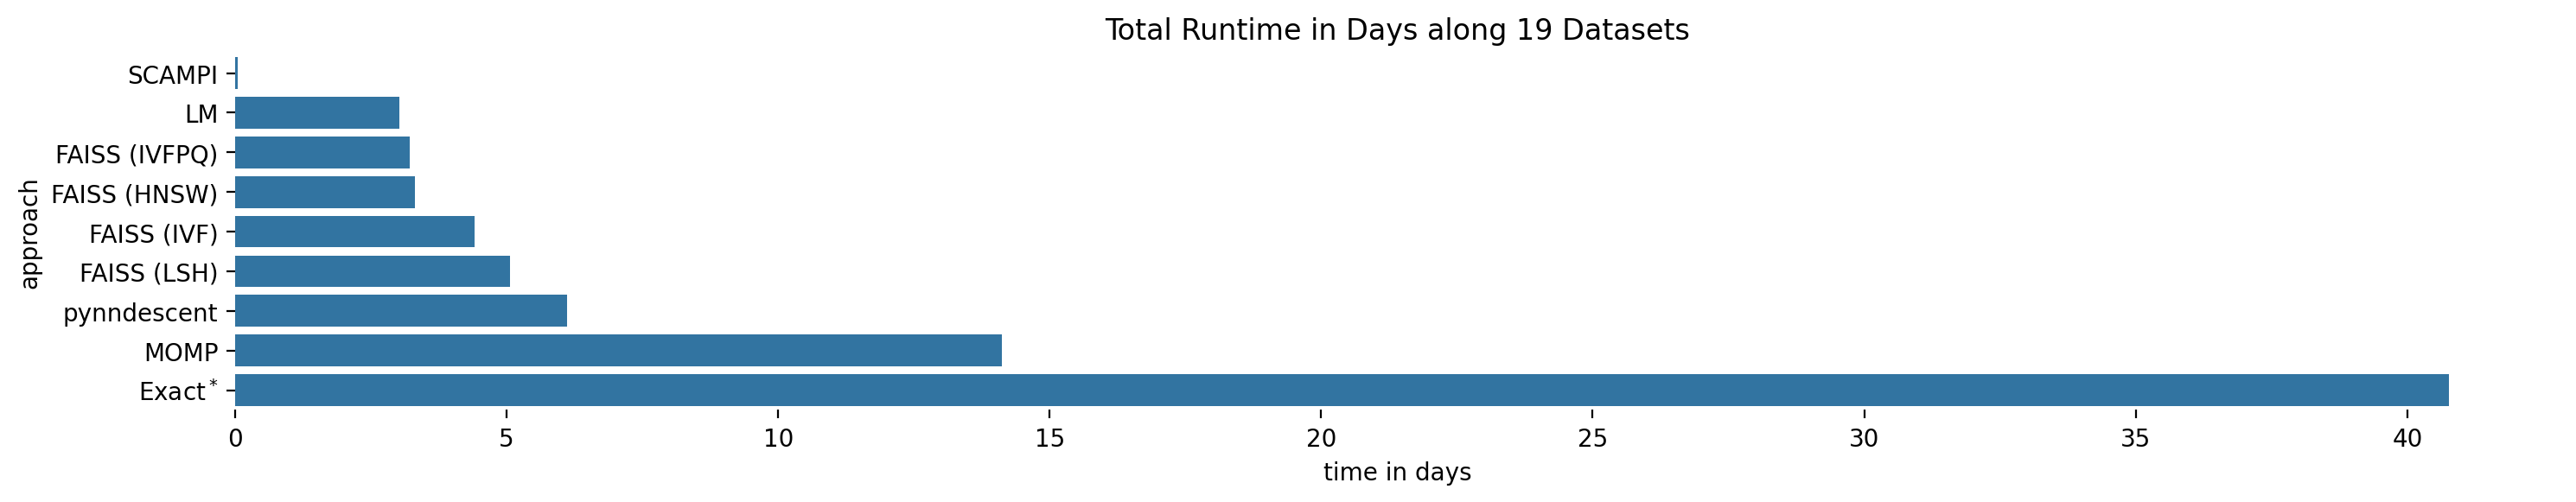

In [14]:
subset = filtered_df.copy().dropna(subset="time in s")
subset = subset[subset["motif length"]<4096]
subset["time in s"] = subset["time in s"] / 3600 / 24
subset = subset.rename(columns={"version" : "approach", "time in s" : "time in days"})
subset = subset.groupby("approach").agg({"time in days":"sum"})
order = subset.sort_values("time in days").index

plt.subplots(figsize=(15,3))
sns.barplot(y="approach", x="time in days", data=subset, order = order)
sns.despine(top=True, left=True, right=True, bottom=True)

# display(subset[["time in days"]])

plt.title(f"Total Runtime in Days along {filtered_df.dataset.nunique()} Datasets")
plt.tight_layout()
plt.savefig("images/all_runtime.pdf", bbox_inches='tight')
plt.show()

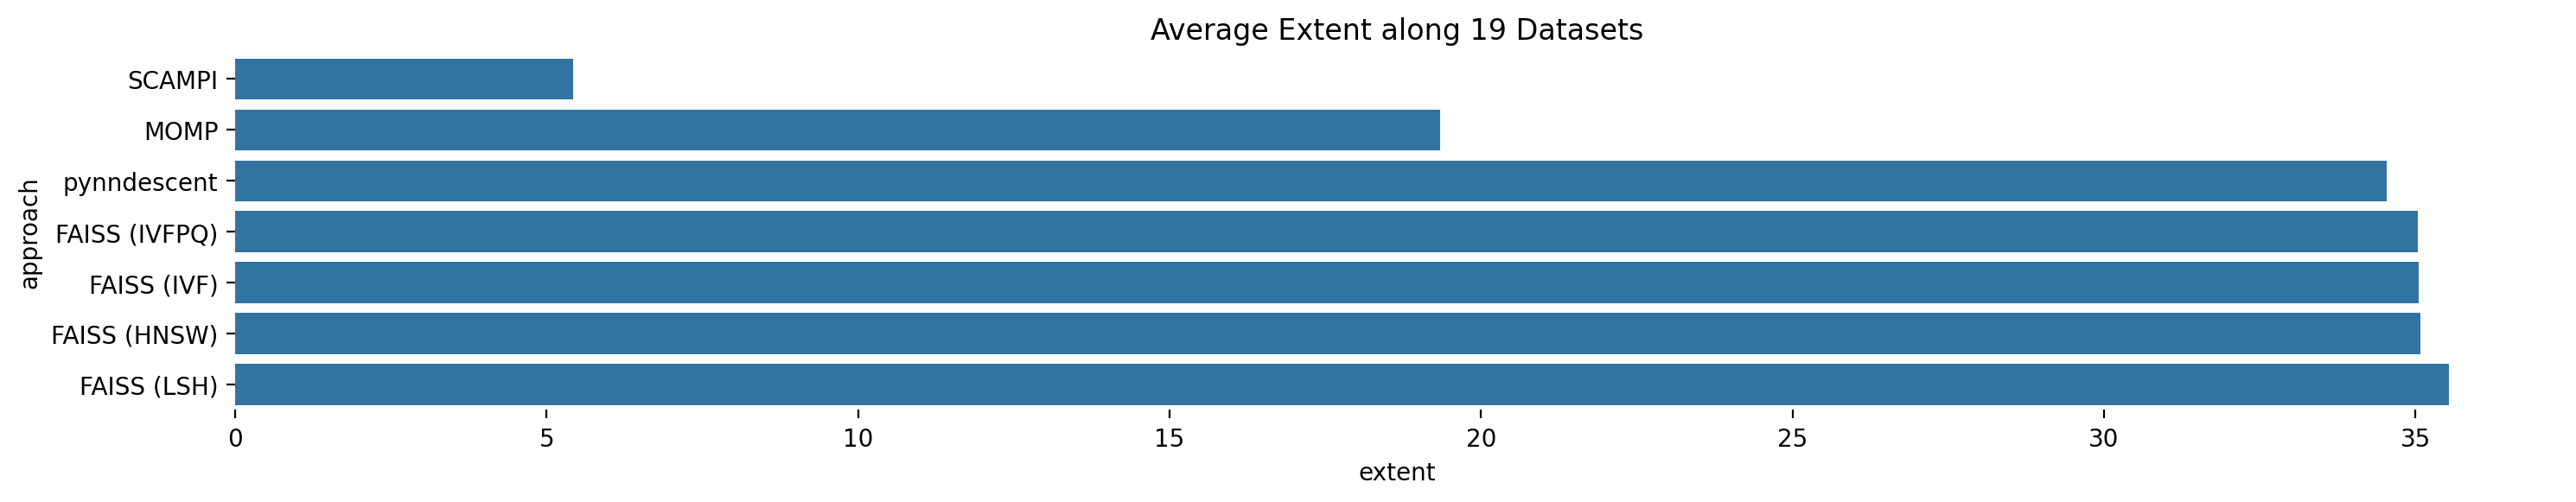

In [15]:
subset = filtered_df.copy().dropna(subset="extent")
subset = subset[subset["motif length"]<4096]
subset["time in s"] = subset["time in s"] / 3600 / 24
subset = subset.rename(columns={"version" : "approach"})
subset = subset.groupby("approach").agg({"extent" : "mean"})
order = subset.sort_values("extent").index

plt.subplots(figsize=(15,3))
sns.barplot(y="approach", x="extent", data=subset, order = order)
sns.despine(top=True, left=True, right=True, bottom=True)

# display(subset[["time in days"]])

plt.title(f"Average Extent along {filtered_df.dataset.nunique()} Datasets")
plt.tight_layout()
plt.savefig("images/all_extent.pdf", bbox_inches='tight')
plt.show()

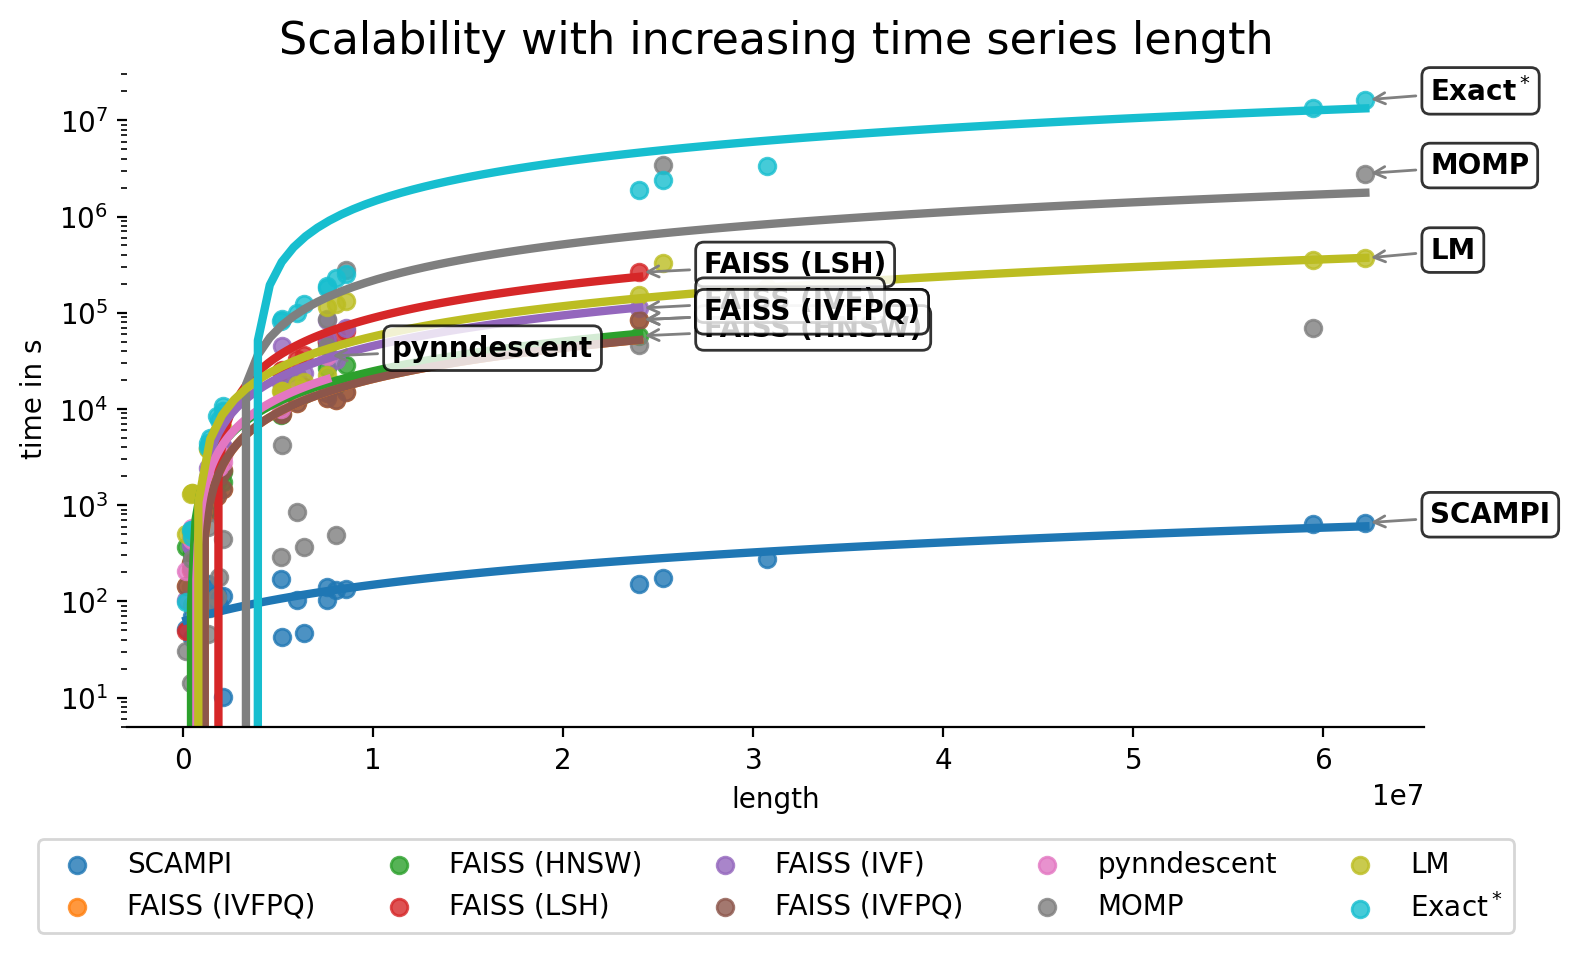

In [16]:
custom_order = ["SCAMPI", 
                "FAISS (IVFPQ)",
                "FAISS (HNSW)",
                "FAISS (LSH)",
                "FAISS (IVF)",
                "FAISS (IVFPQ)",
                "pynndescent",
                "MOMP",
                "LM",
                "Exact$^*$"                
               ]

subset = df_all.copy()
subset = subset[(subset["motif length"]==4096)]
subset = subset[subset.version.isin(custom_order)]    

palette = sns.color_palette("tab10", n_colors=len(custom_order))

#display(subset)
fig, ax = plt.subplots(figsize=(8,5))

for i, order in enumerate(custom_order):
    df_order = subset[subset['version'] == order].convert_dtypes()
    color = palette[i]
    # display(df_order[["length","time in s"]].info())
    sns.regplot(data=df_order, x="length", y="time in s", 
                label=order, 
                ci=0, scatter=True, 
                fit_reg=True, robust=True, truncate=True,
                scatter_kws={'color': color},
                line_kws={'color': color, 'linewidth': 3},                
                ax=ax)


texts = []  # Collect annotations here
for order in custom_order:
    df_order = subset[subset['version'] == order].sort_values('length')
    if not df_order.empty:
        last_point = df_order.iloc[-1]
        x_last, y_last = last_point['length'], last_point['time in s']
        text = ax.annotate(
            order, xy=(x_last, y_last), 
            xytext=(x_last + 0.05 * (ax.get_xlim()[1] - ax.get_xlim()[0]), y_last),
            ha='left', fontsize=10, 
            color='black', weight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
            arrowprops=dict(arrowstyle='->', color='gray')
        )
        texts.append(text)


# g = sns.lmplot(hue="version", x="length", y="time in s", data=subset, ci=10, height=6)
sns.despine(top=True, left=True, right=True) # , bottom=True
plt.yscale('log')
# plt.xscale('log')

plt.title(f"Scalability with increasing time series length", fontsize=16)
plt.legend(loc='upper center', ncols=5, bbox_to_anchor=(0.5, -0.15), ncol=len(custom_order))


plt.tight_layout()
plt.savefig("images/scalability.pdf", bbox_inches='tight')
plt.show()

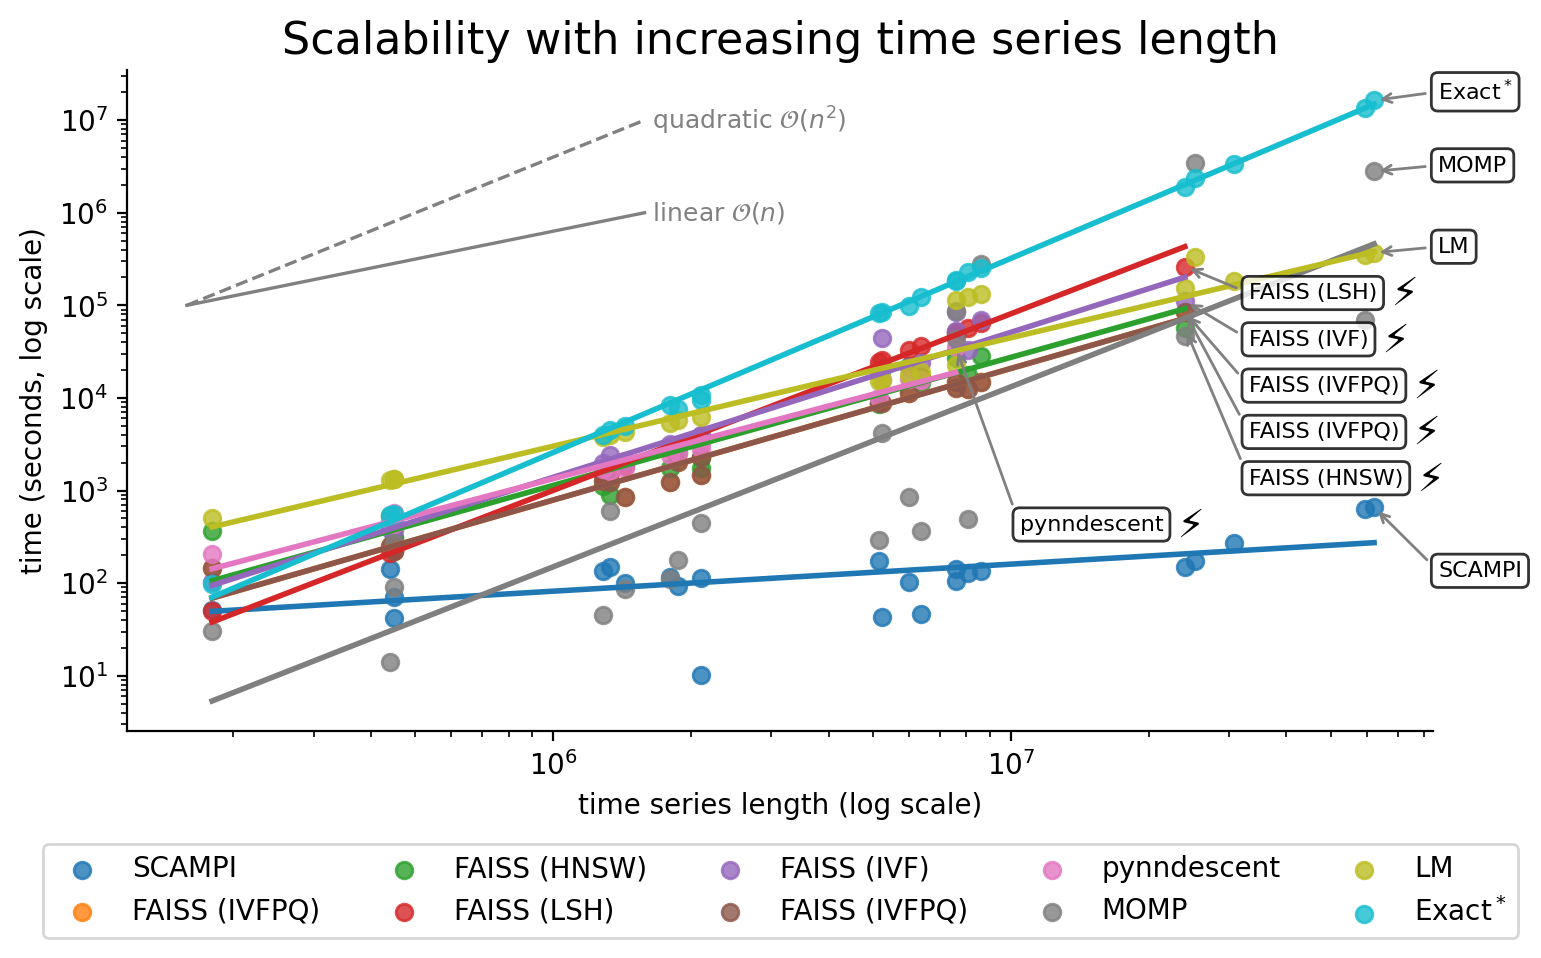

In [70]:
# custom version for SIGMOD paper
from adjustText import adjust_text
custom_order = ["SCAMPI", 
                "FAISS (IVFPQ)",
                "FAISS (HNSW)",
                "FAISS (LSH)",
                "FAISS (IVF)",
                "FAISS (IVFPQ)",
                "pynndescent",
                "MOMP",
                "LM",
                "Exact$^*$"                
               ]

subset = df_all.copy()
subset = subset[(subset["motif length"]==4096)]
subset = subset[subset.version.isin(custom_order)]    
subset["log length"] = np.log10(subset["length"].astype(np.float64))
subset["log time in s"] = np.log10(subset["time in s"])

palette = sns.color_palette("tab10", n_colors=len(custom_order))

#display(subset)
fig, ax = plt.subplots(figsize=(8,5))

for i, order in enumerate(custom_order):
    df_order = subset[subset['version'] == order].convert_dtypes()
    color = palette[i]
    sns.regplot(data=df_order, x="log length", y="log time in s", 
                label=order, 
                ci=None, scatter=True,
                fit_reg=True, robust=True, truncate=True,
                scatter_kws={'color': color},
                line_kws={'color': color, 'linewidth': 2},                
                ax=ax)
    # sns.scatterplot(
    #     data=df_order, x="log length", y="log time in s", 
    #     label=order, 
    #     color=color,          
    #     ax=ax,
    #     legend=False,
    #     zorder=100
    # )


annotations = []
for order in custom_order:
    df_order = subset[subset['version'] == order].sort_values('length')
    if not df_order.empty:
        last_point = df_order.iloc[-1]
        x_last, y_last = last_point['log length'], last_point['log time in s']
        annotations.append((float(y_last), float(x_last), order))
annotations = sorted(annotations, reverse=True)
spacing = 0.5
last_y = float("infinity")
texts = []
for y, x, label in annotations:
    if last_y - y < spacing:
        annoty = last_y - spacing
    else:
        annoty = y
    last_y = annoty
    text = ax.annotate(
        label, xy=(x, y), 
        xytext=(x + 0.05 * (ax.get_xlim()[1] - ax.get_xlim()[0]), annoty),
        ha='left', fontsize=8, 
        color='black', weight='normal',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
        arrowprops=dict(arrowstyle='->', color='gray', relpos=(0.0, 0.5))
    )
    texts.append(text)

minor_yticks = []
yticks = ax.yaxis.get_ticklocs()
ax.set_yticklabels([f"$10^{{{int(t)}}}$" for t in yticks])
for major in yticks[:-1]:
    minor_yticks.extend([np.log10(x*10**major) for x in range(2,10)])
ax.set_yticks(minor_yticks, minor=True)
ax.set_yticklabels([], minor=True)

xticks = [5, 6, 7, 8]
minor_xticks = []
for major in xticks[:-1]:
    minor_xticks.extend([np.log10(x*10**major) for x in range(2,10)])
ax.set_xticks(xticks)
ax.set_xticklabels([f"$10^{{{t}}}$" for t in xticks])
ax.set_xticks(minor_xticks, minor=True)
ax.set_xticklabels([], minor=True)

sns.despine(top=True, left=False, right=True) # , bottom=True

plt.title(f"Scalability with increasing time series length", fontsize=16)
plt.legend(loc='upper center', ncols=5, bbox_to_anchor=(0.5, -0.15), ncol=len(custom_order))
plt.xlabel("time series length (log scale)")
plt.ylabel("time (seconds, log scale)")

# Reference slope lines, drawn in the same coordinate system as the data
anchor_x, anchor_y = 5.2, 5.0   # pick an empty spot in the plot; adjust as needed
dx = 1                         # horizontal length of the segments (in log10 units)

# Linear: slope 1
ax.plot([anchor_x, anchor_x + dx], [anchor_y, anchor_y + 1 * dx],
        color='gray', linewidth=1.2, linestyle='-')
ax.text(anchor_x + dx, anchor_y + 1 * dx, r' linear $\mathcal{O}(n)$',
        va='center', ha='left', fontsize=9, color='gray')

# Quadratic: slope 2
ax.plot([anchor_x, anchor_x + dx], [anchor_y, anchor_y + 2 * dx],
        color='gray', linewidth=1.2, linestyle='--')
ax.text(anchor_x + dx, anchor_y + 2 * dx, r' quadratic $\mathcal{O}(n^2)$',
        va='center', ha='left', fontsize=9, color='gray')

plt.tight_layout()

fig.canvas.draw()  # force render so bboxes are computed
renderer = fig.canvas.get_renderer()
for text in ax.texts:
    if text.get_text().startswith("FAISS") or text.get_text() == "pynndescent":
            
        # Bounding box in display (pixel) coordinates
        bbox_display = text.get_window_extent(renderer)
        bbox_data = ax.transData.inverted().transform(bbox_display)
        # print(f"'{text.get_text()}' pixels: {bbox_display}")
    
        ax.text(
            bbox_data[1,0],  # right edge x of the box
            bbox_data[0,1] + 0.1,
            ' ⚡',
            # " 💥",
            ha='left', va='center',
            weight="bold",
            fontsize=14,
        )

inset.set_aspect('equal')
plt.savefig("images/scalability.pdf", bbox_inches='tight')
plt.show()

,time in days,extent,speedup
approach,,,
SCAMPI,2.4e-02,15.9,1.0
pynndescent,1.3e+00,80.1,53.6
FAISS (IVFPQ),2.3e+00,81.4,95.8
FAISS (HNSW),3.0e+00,80.6,126.1
MOMP,5.3e+00,28.4,224.1
FAISS (IVF),5.6e+00,80.6,234.5
FAISS (LSH),7.2e+00,82.7,305.1
LM,7.5e+00,NaN,316.5
Exact$^*$,3.7e+01,NaN,1555.0


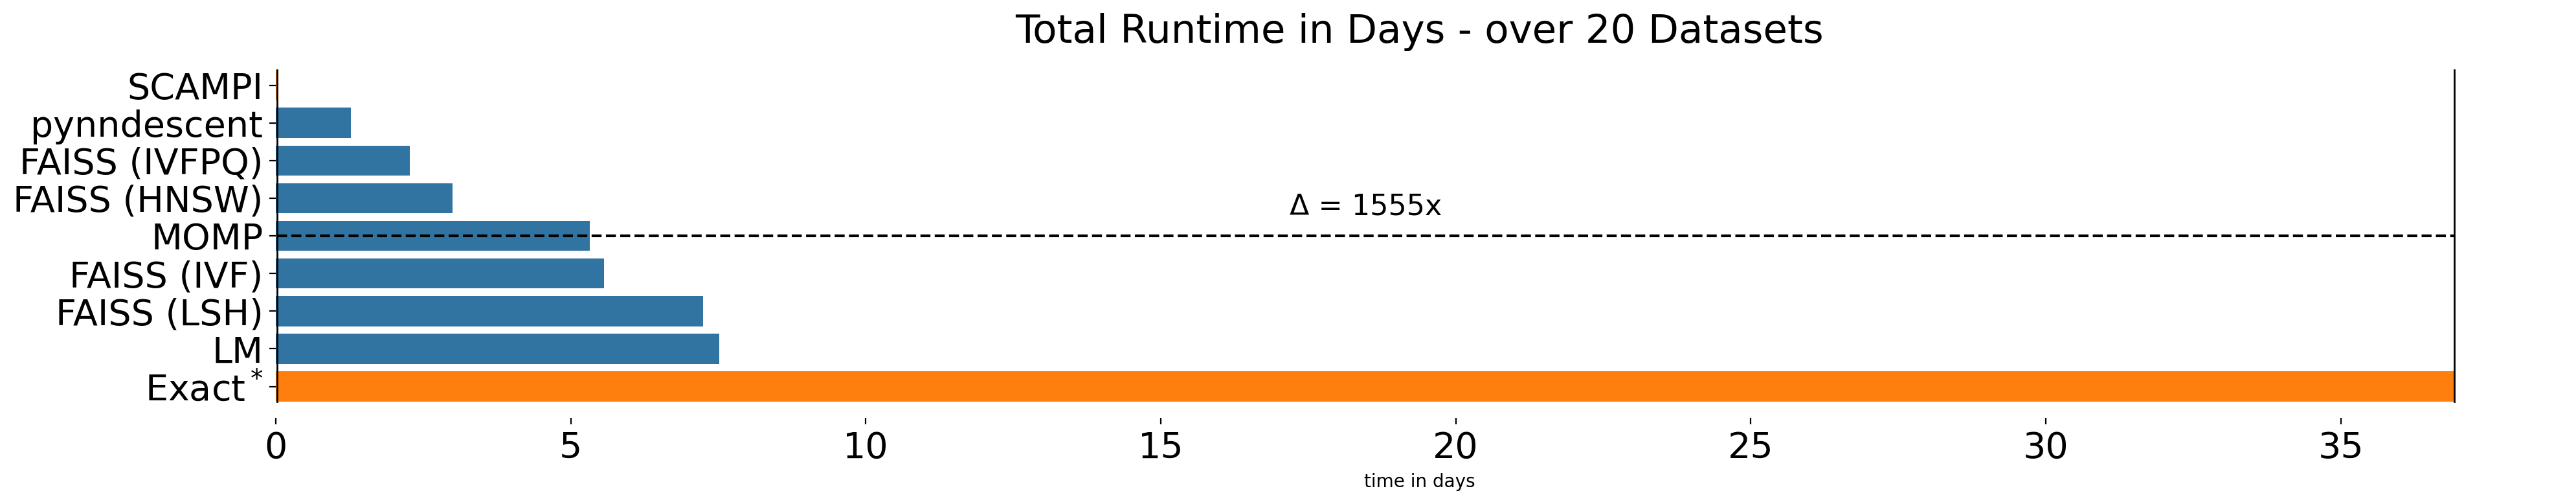

In [17]:
def plot(datasets, length=4096):
    custom_order = ["SCAMPI", 
                    "FAISS (IVFPQ)",
                    "FAISS (HNSW)",
                    "FAISS (LSH)",
                    "FAISS (IVF)",
                    "FAISS (IVFPQ)",
                    "pynndescent",
                    "MOMP",
                    "LM",
                    "Exact$^*$"  
                   ]
    
    filtered_df = df_all[df_all["dataset"].isin(datasets)]
    filtered_df = filtered_df[df_all.version.isin(custom_order)]    
    filtered_df = filtered_df[filtered_df["motif length"] == length]
    
    subset = filtered_df.copy()
    subset["time in s"] = subset["time in s"] / 3600 / 24
    subset = subset.rename(columns={"version" : "approach", "time in s" : "time in days"})
    subset = subset.groupby("approach").agg({"time in days" : "sum", "extent" : "median"})
    order = subset.sort_values("time in days").index
    
    fig, ax = plt.subplots(figsize=(20,4))
    sns.barplot(y="approach", x="time in days", data=subset, order = order, ax = ax)
    sns.despine(top=True, left=True, right=True, bottom=True)
    
    ax = plt.gca() 
    bars = ax.patches
    first_bar = bars[0]
    last_bar = bars[-1]
    first_bar.set_facecolor("#ff7f0e")
    last_bar.set_facecolor("#ff7f0e")
    
    v1 = first_bar.get_width() 
    v2 = last_bar.get_width()
    y_top = last_bar.get_y() + last_bar.get_height()
    y_bottom = first_bar.get_y()
    y_center = (y_top + y_bottom) / 2
    
    ax.plot([v1, v2], [y_center, y_center], color="black", linestyle="--", linewidth=1.5, zorder=3)
    ax.plot([v1, v1], [y_bottom, y_top], color="black", linestyle="-", linewidth=1.0, zorder=3)
    ax.plot([v2, v2], [y_bottom, y_top], color="black", linestyle="-", linewidth=1.0, zorder=3)

    max_d = subset["time in days"].max()
    min_d = subset["time in days"].min()

    speedup = subset.transform (lambda l: l / l.min())
    subset["speedup"] = speedup["time in days"]
    subset = subset.sort_values("time in days", ascending=False)

    display(subset.sort_values("speedup"))
    factor = max_d / min_d
    ax.text((v1 + v2) / 2, y_center-0.4, f"Δ = {factor:.0f}x",
                ha="center", va="bottom", fontsize=16, zorder=4)
    
    n_datasets = filtered_df.dataset.nunique()
    # plt.xscale('log')

    plt.xticks(fontsize=20)
    ax.set_ylabel("")
    plt.yticks(fontsize=20)
    if len(datasets) > 1:
        plt.title(f"Total Runtime in Days - over {n_datasets} Datasets", fontsize=22)
    else: 
        plt.title(f"Runtime in Days - {datasets[0]}", fontsize=22)
    plt.tight_layout()

plot(datasets_to_keep)
plt.savefig("images/runtime_total.pdf", bbox_inches='tight')
plt.show()


In [18]:
#subset.groupby("approach") \
#    .agg({"time in days": "sum"}) \
#    .sort_values("time in days") \
#    .transform(lambda l: l / l.iloc[0]["time in days"]).rename(columns={"time in h":"speedup"})

,time in days,extent,speedup
approach,,,
SCAMPI,1.7e-03,5.5e-04,1.0
MOMP,5.3e-01,9.1e+01,307.4
FAISS (HNSW),6.6e-01,2.6e+01,382.5
FAISS (IVFPQ),9.8e-01,1.5e+01,563.1
FAISS (IVF),1.3e+00,2.6e+01,742.9
LM,1.8e+00,NaN,1017.4
FAISS (LSH),3.0e+00,2.9e+01,1748.3
Exact$^*$,2.2e+01,NaN,12635.2


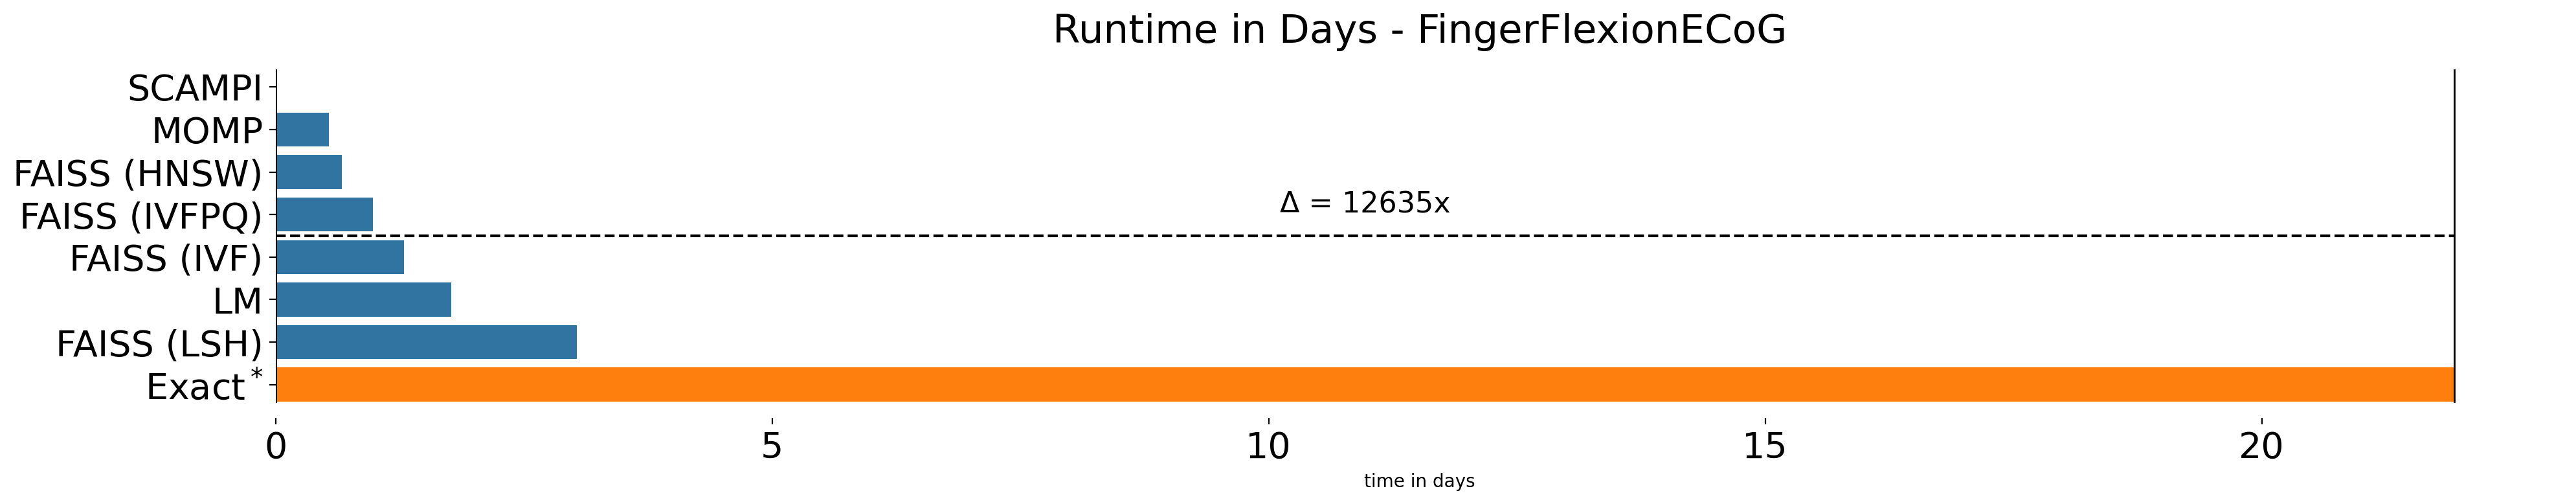

In [19]:
#plot(["WindTurbine"])
#plt.savefig("images/windturbine.pdf")
#plt.show()

plot(["FingerFlexionECoG"])
plt.savefig("images/FingerFlexionECoG.pdf", bbox_inches='tight')
plt.show()


In [20]:
# filtered_df.groupby("dataset").head(1)[["length", "dataset"]].sort_values("length").reset_index(drop=True)

In [21]:
# df_all.groupby("dataset").head(1)[["length", "dataset"]].sort_values("dataset").reset_index(drop=True)

,time in days,extent,speedup
approach,,,
Exact$^*$,2.2e+01,NaN,12635.2
FAISS (LSH),3.0e+00,2.9e+01,1748.3
LM,1.8e+00,NaN,1017.4
FAISS (IVF),1.3e+00,2.6e+01,742.9
FAISS (IVFPQ),9.8e-01,1.5e+01,563.1
FAISS (HNSW),6.6e-01,2.6e+01,382.5
MOMP,5.3e-01,9.1e+01,307.4
SCAMPI,1.7e-03,5.5e-04,1.0


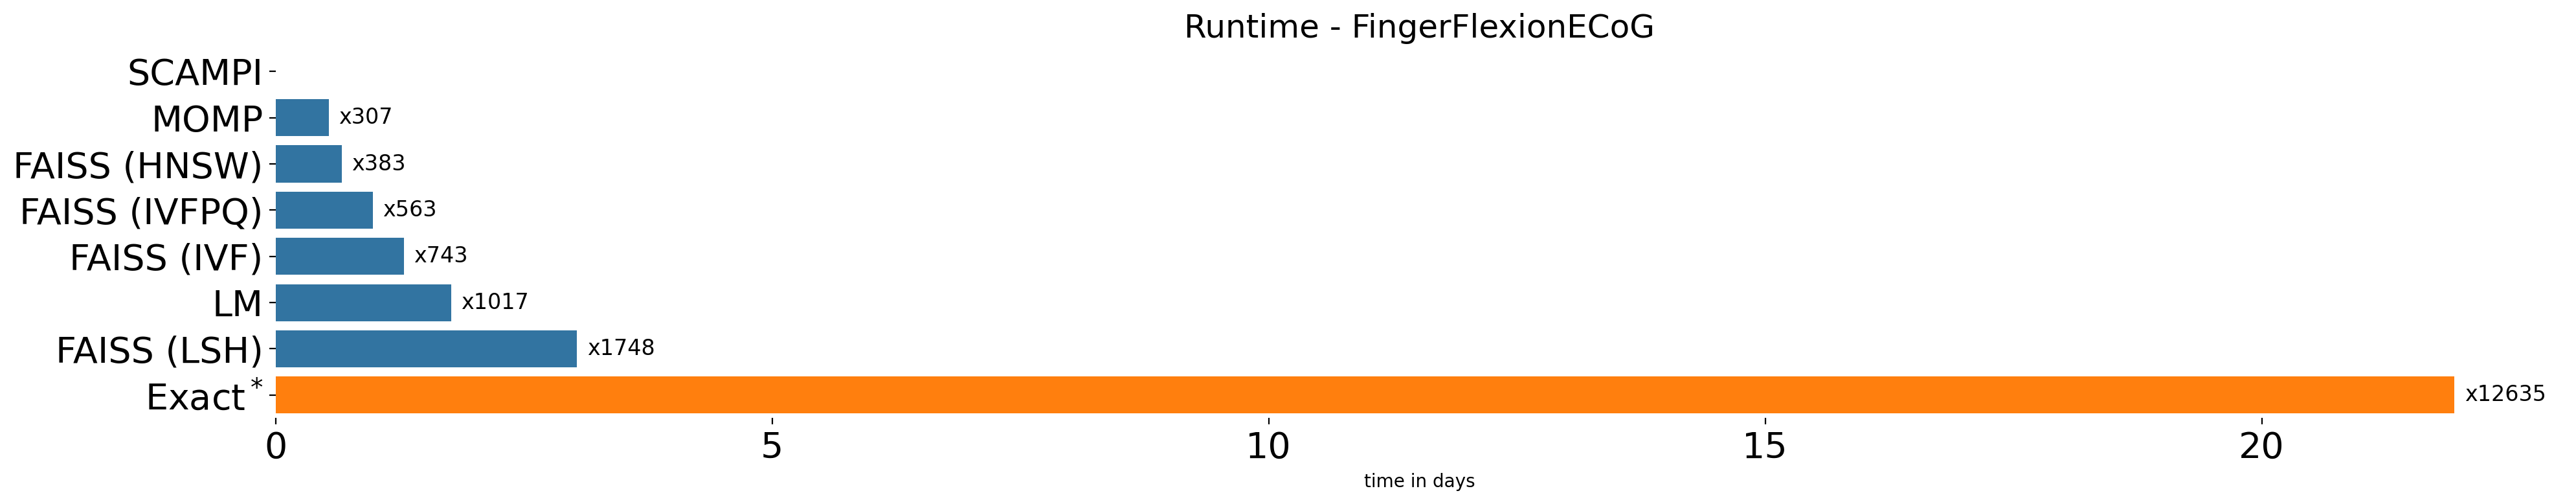

In [22]:
def plot2(datasets, length=4096):
    custom_order = ["SCAMPI",
                    "FAISS (IVFPQ)",
                    "FAISS (HNSW)",
                    "FAISS (LSH)",
                    "FAISS (IVF)",
                    "FAISS (IVFPQ)",
                    "pynndescent",
                    "MOMP",
                    "LM",
                    "Exact$^*$"  
                   ]
    
    filtered_df = df_all[df_all["dataset"].isin(datasets)]
    filtered_df = filtered_df[df_all.version.isin(custom_order)]    
    filtered_df = filtered_df[filtered_df["motif length"] == length]
    
    subset = filtered_df.copy()
    subset["time in s"] = subset["time in s"] / 3600 / 24
    subset = subset.rename(columns={"version" : "approach", "time in s" : "time in days"})
    subset = subset.groupby("approach").agg({"time in days" : "sum", "extent" : "median"})
    order = subset.sort_values("time in days").index

    fig, ax = plt.subplots(figsize=(20,4))
    sns.barplot(y="approach", x="time in days", data=subset, order = order, ax = ax)
    sns.despine(top=True, left=True, right=True, bottom=True)
    
    ax = plt.gca() 
    bars = ax.patches
    first_bar = bars[0]
    last_bar = bars[-1]
    first_bar.set_facecolor("#ff7f0e")
    last_bar.set_facecolor("#ff7f0e")
    
    speedup = subset.transform (lambda l: l / l.min())
    subset["speedup"] = speedup["time in days"]
    subset = subset.sort_values("time in days", ascending=False)

    display(subset)
    
    # Annotate each bar with its speedup value
    for bar, speed in zip(ax.patches[1:], reversed(subset["speedup"].iloc[:-1])):
        width = bar.get_width()
        y = bar.get_y() + bar.get_height() / 2
        ax.text(
            width + 0.1, y,  # 0.1 units offset right from bar end
            f"x{speed:.0f}",
            va='center', ha='left',
            fontsize=12,
            color='black'
        )
        
    n_datasets = filtered_df.dataset.nunique()

    plt.xticks(fontsize=20)
    ax.set_ylabel("")
    plt.yticks(fontsize=20)
    if len(datasets) > 1:
        plt.title(f"Total Runtime in Days - over {n_datasets} Datasets", fontsize=18)
    else: 
        plt.title(f"Runtime - {datasets[0]}", fontsize=18)
    plt.tight_layout()

plot2(["FingerFlexionECoG"])
plt.savefig("images/FingerFlexionECoG.pdf", bbox_inches='tight')
plt.show()

In [23]:
# df_all[(df_all.version == "Exact$^*$") & (df_all.length > 10**6)].sort_values("length")# ["time in s"] # / 3600 #  / 24